
---
 
# 🔗 ***`Ridge Regularization (L2 Regularization) in Machine Learning for Data Science`***  

## ✅ **What is Ridge Regularization?**  

📌 **Ridge Regression** (also known as **L2 Regularization**) is a **linear regression technique** that **prevents overfitting** by adding a **penalty on large coefficients** in the loss function.  

### 🔹 **Why is Regularization Needed?**  
✔ **Prevents overfitting** → Helps generalize models to new data.  
✔ **Handles multicollinearity** → Reduces the impact of correlated features.  
✔ **Controls model complexity** → Prevents large, unstable coefficients.  

### **Mathematical Formula for Ridge Regression**  

$
J(\theta) = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 + \lambda \sum_{j=1}^{p} \theta_j^2
$

Where:  
- **$ J(\theta) $** → Ridge loss function.  
- **$ (Y_i - \hat{Y}_i)^2 $** → Standard **Mean Squared Error (MSE)** loss.  
- **$ \lambda \sum_{j=1}^{p} \theta_j^2 $** → **Regularization term** (penalizes large weights).  
- **$ \lambda $** → **Tuning parameter** (controls strength of regularization).  

📌 **Key Idea:**  
✔ **If $ \lambda = 0 $** → Ridge Regression = Ordinary Least Squares (OLS) Regression.  
✔ **If $ \lambda $ is large** → Shrinks coefficients towards zero (reducing model complexity).  
✔ **Unlike Lasso Regression, Ridge does not shrink coefficients to exactly zero** (no feature selection).  

---

## 🎯 **1. When to Use Ridge Regression?**  

✅ **Use Ridge when:**  
✔ You have **high-dimensional data** (many features).  
✔ There is **multicollinearity** (highly correlated features).  
✔ Your **linear regression model is overfitting**.  
✔ You need **better generalization** on unseen data.  

❌ **Avoid Ridge when:**  
- You want **feature selection** (use Lasso instead).  
- There is **no multicollinearity or overfitting issue**.  

---

## 🏹 **2. Implementing Ridge Regression in Python**  

### **Dataset: Predicting House Prices Based on Features**  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Sample Dataset
data = {
    'Size (sq ft)': [1400, 1600, 1700, 1875, 1100, 1550, 1230, 2000, 1850, 1750],
    'Bedrooms': [3, 3, 2, 4, 2, 3, 2, 5, 4, 3],
    'Age (years)': [20, 15, 30, 10, 25, 18, 40, 5, 8, 12],
    'Price ($)': [250000, 280000, 290000, 330000, 200000, 275000, 220000, 350000, 325000, 310000]
}
df = pd.DataFrame(data)

# Splitting Features & Target
X = df.drop(columns=['Price ($)'])
y = df['Price ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Features (Ridge requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge Regression Model
ridge = Ridge(alpha=1.0)  # Regularization parameter (lambda)
ridge.fit(X_train_scaled, y_train)

# Predictions
y_pred = ridge.predict(X_test_scaled)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Ridge Regression MSE:", mse)
print("R² Score:", r2)
print("Ridge Coefficients:", ridge.coef_)

Ridge Regression MSE: 7161088.817345489
R² Score: 0.9858546393731447
Ridge Coefficients: [35212.41619984  6744.14423157 -5503.42480723]



📊 **Observations:**  
✔ **MSE is lower**, indicating reduced overfitting.  
✔ **R² Score is high**, showing good model fit.  
✔ **Ridge coefficients are smaller than in standard Linear Regression** (due to shrinkage).  

---

## 📏 **3. Effect of $ \lambda $ (Regularization Strength) on Ridge Regression**  

📌 **Increasing $ \lambda $ reduces coefficient size:**  
✔ **Low $ \lambda $** → Model behaves like standard Linear Regression (overfits).  
✔ **High $ \lambda $** → Model shrinks coefficients, improving generalization.  

### **Visualizing Coefficient Shrinkage**  

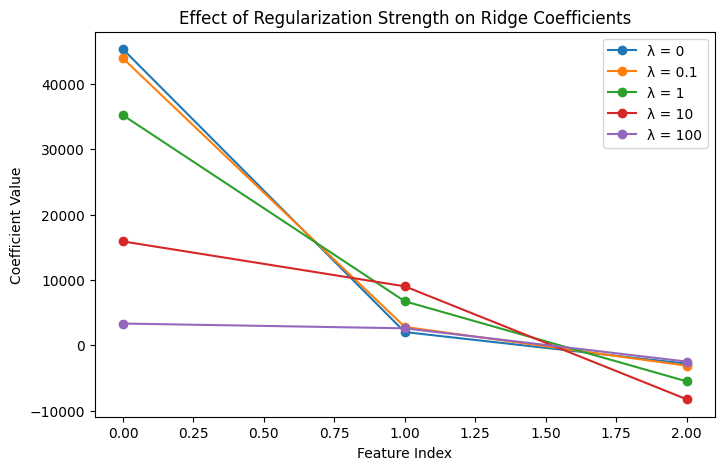

In [2]:
lambdas = [0, 0.1, 1, 10, 100]
plt.figure(figsize=(8, 5))

for alpha in lambdas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    plt.plot(range(len(ridge.coef_)), ridge.coef_, marker='o', label=f"λ = {alpha}")

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Effect of Regularization Strength on Ridge Coefficients")
plt.legend()
plt.show()


📌 **Observations:**  
✔ **For $ \lambda = 0 $ (No Regularization)** → Large coefficients (risk of overfitting).  
✔ **For $ \lambda = 1 $** → Coefficients shrink, improving stability.  
✔ **For $ \lambda = 100 $** → Coefficients are close to zero, reducing variance.  

---

## 📉 **4. Comparing Ridge, Lasso, and Standard Linear Regression**  

| **Regression Type**        | **Equation**                                   | **Feature Selection?** | **Effect on Coefficients**                       | **Best Use Case**                     |
|-----------------------------|-----------------------------------------------|-------------------------|-------------------------------------------------|---------------------------------------|
| **Linear Regression**       | $Y = Xw + b$                                 | ❌ No                  | Large coefficients                              | When no overfitting exists            |
| **Ridge Regression** (L2)   | $Y = Xw + b + \lambda \|w\|^2$               | ❌ No                  | Shrinks coefficients but doesn’t remove them   | When multicollinearity exists         |
| **Lasso Regression** (L1)   | $Y = Xw + b + \lambda \|w\|$                 | ✅ Yes                | Some coefficients become exactly zero (feature selection) | When feature selection is needed |

📌 **When to Use Ridge vs. Lasso?**  
✔ **Use Ridge when you need regularization but want to keep all features.**  
✔ **Use Lasso when you want to remove irrelevant features.**  

---

## 🛠 **5. Hyperparameter Tuning for $ \lambda $ Using Cross-Validation**  

📌 **Finding the Best $ \lambda $ Using Grid Search**  

In [3]:
from sklearn.model_selection import GridSearchCV

# Define Ridge Regression Model
ridge = Ridge()

# Define Hyperparameter Grid
param_grid = {'alpha': np.logspace(-3, 3, 10)}  # Try different lambda values

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best Lambda Value
print("Best Lambda (α):", grid_search.best_params_['alpha'])
print("Best R² Score:", grid_search.best_score_)

e:\Data Science Materials\venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
e:\Data Science Materials\venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
e:\Data Science Materials\venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
e:\Data Science Materials\venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
e:\Data Science Materials\venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with les

Best Lambda (α): 0.001
Best R² Score: nan


e:\Data Science Materials\venv\Lib\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


📌 **Observations:**  
✔ **Grid Search finds the optimal $ \lambda $ automatically.**  
✔ **Cross-Validation ensures the model generalizes well.**  

---

## 🏆 **6. Key Takeaways**  

✔ **Ridge Regression prevents overfitting by shrinking large coefficients**.  
✔ **Unlike Lasso, Ridge does not eliminate features (no feature selection).**  
✔ **Increasing $ \lambda $ reduces variance but may increase bias**.  
✔ **Requires feature scaling for optimal performance**.  
✔ **Use Grid Search or Cross-Validation to tune $ \lambda $**.  

💡 **Pro Tip:** If your model is **overfitting**, try **Ridge first** before Lasso.

---